In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
class FastSpeech2Config:
    vocab_size: int=44
    padding_idx: int=0
    d_model: int =256
    encoder_layers: int=4
    decoder_layers: int=4
    encoder_heads: int=2
    decoder_heads: int=2
    ffn_hidden: int=1024
    dropout: float=0.1
    variance_predictor_hidden: int=256
    variance_predictor_kernel:int=3
    variance_predictor_dropout:float=0.1
    pitch_n_bins: int=256
    energy_n_bins: int=256
    n_mels: int=80
    speaker_embed_dim: int=256
fscfg=FastSpeech2Config()
print("FastSpeech2 Config:")
print(f"  Vocab size:    {fscfg.vocab_size}")
print(f"  d_model:       {fscfg.d_model}")
print(f"  Encoder:       {fscfg.encoder_layers} layers × {fscfg.encoder_heads} heads")
print(f"  Decoder:       {fscfg.decoder_layers} layers × {fscfg.decoder_heads} heads")
print(f"  FFN hidden:    {fscfg.ffn_hidden}")
print(f"  Output:        {fscfg.n_mels} mel bins")


FastSpeech2 Config:
  Vocab size:    44
  d_model:       256
  Encoder:       4 layers × 2 heads
  Decoder:       4 layers × 2 heads
  FFN hidden:    1024
  Output:        60 mel bins


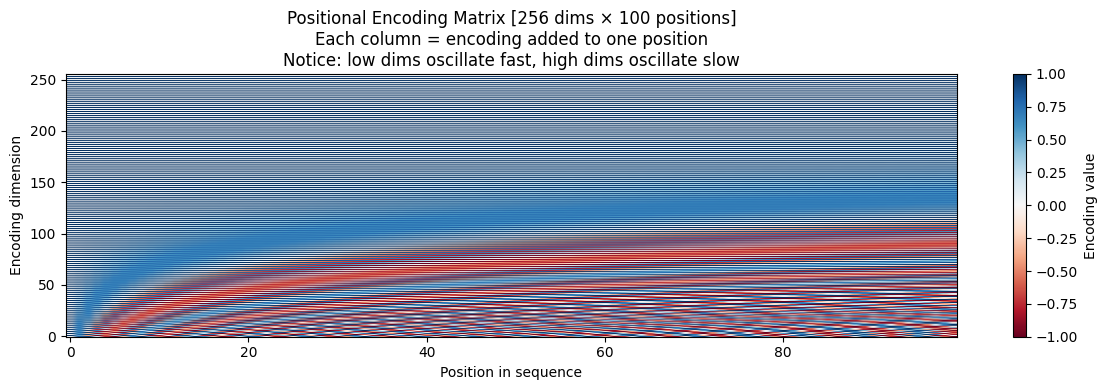

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len:int=5000,dropout:float=0.1):
        super().__init__()
        self.dropout=nn.Dropout(p=dropout)
        pe=torch.zeros(max_len,d_model)
        position=torch.arange(0,max_len).unsqueeze(1).float()
        div_term=torch.exp(
            torch.arange(0,d_model,2).float()*(-math.log(10000.0)/d_model)
        )
        pe[:,0::2]=torch.sin(position*div_term)
        pe[:,1::2]=torch.cos(position*div_term)
        pe=pe.unsqueeze(0)
        self.register_buffer("pe",pe)
    
    def forward(self, x: torch.Tensor)->torch.Tensor:
        x=x+self.pe[:, :x.size(1)]
        return self.dropout(x)
pe_module = PositionalEncoding(d_model=256, dropout=0.0)
dummy_input = torch.zeros(1, 100, 256)   # 100 positions, 256 dims
pe_output = pe_module(dummy_input)
pe_matrix = pe_output[0].detach().numpy()   # [100, 256]

plt.figure(figsize=(12, 4))
plt.imshow(pe_matrix.T, aspect="auto", cmap="RdBu", origin="lower")
plt.colorbar(label="Encoding value")
plt.title("Positional Encoding Matrix [256 dims × 100 positions]\n"
          "Each column = encoding added to one position\n"
          "Notice: low dims oscillate fast, high dims oscillate slow")
plt.xlabel("Position in sequence")
plt.ylabel("Encoding dimension")
plt.tight_layout()
plt.show()



In [ ]:
class FeedForward(nn.Module):
    def __init__(self, d_model: int, ffn_hidden: int, dropout: float=0.1):
        super().__init__()
        self.linear1=nn.Linear(d_model,ffn_hidden)
        self.linear2=nn.Linear(ffn_hidden,d_model)
        self.dropout=nn.Dropout(dropout)
    def forward(self, x: torch.Tensor)->torch.Tensor:
        x=self.linear1(x)
        x=F.relu(x)
        x=self.dropout(x)
        x=self.linear2(x)
        return x
ffn = FeedForward(d_model=256, ffn_hidden=1024)
dummy = torch.randn(2, 10, 256)
out = ffn(dummy)
print(f"FFN: {dummy.shape} → {out.shape}  (shape preserved)")

FFN: torch.Size([2, 10, 256]) → torch.Size([2, 10, 256])  (shape preserved)


In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self,d_model:int,n_heads:int,ffn_hidden:int,dropout: float=0.1):
        super().__init__()
        self.attention=nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )
        self.ffn=FeedForward(d_model,ffn_hidden,dropout)
        self.norm1=nn.LayerNorm(d_model)
        self.norm2=nn.LayerNorm(d_model)
        self.dropout=nn.Dropout(dropout)
    def forward(self, x:torch.Tensor,key_padding_mask:torch.Tensor=None)->torch.Tensor:
        residual=x
        x=self.norm1(x)
        x,_=self.attention(
            query=x,
            key=x,
            value=x,
            key_padding_mask=key_padding_mask
        )
        x=self.dropout(x)
        x=x+residual
        residual=x
        x=self.norm2(x)
        x=self.ffn(x)
        x=self.dropout(x)
        x=x+residual
        return x
block = TransformerBlock(d_model=256, n_heads=2, ffn_hidden=1024)
dummy = torch.randn(2, 15, 256)   # batch=2, seq_len=15, d_model=256
out   = block(dummy)
print(f"TransformerBlock: {dummy.shape} → {out.shape}  (shape preserved)")

TransformerBlock: torch.Size([2, 15, 256]) → torch.Size([2, 15, 256])  (shape preserved)


In [ ]:
class VariancePredictor(nn.Module):
    def __init__(self,config: FastSpeech2Config):
        super().__init__()
        in_channels=config.d_model
        hidden=config.variance_predictor_hidden
        kernel=config.variance_predictor_kernel
        padding=kernel//2
        dropout=config.variance_predictor_dropout
        self.conv1=nn.Conv1d(in_channels,hidden,kernel,padding=padding)
        self.norm1=nn.LayerNorm(hidden)
        self.conv2 = nn.Conv1d(hidden, hidden, kernel, padding=padding)        
        self.norm2=nn.LayerNorm(hidden)
        self.linear=nn.Linear(hidden,1)
        self.dropout=nn.Dropout(dropout)
    def forward(self, x: torch.Tensor,mask:torch.Tensor=None)->torch.Tensor:
        x=x.transpose(1,2)
        x=self.conv1(x)
        x=x.transpose(1,2)
        x=self.norm1(x)
        x=F.relu(x)
        x=self.dropout(x)

        x=x.transpose(1,2)
        x=self.conv2(x)
        x=x.transpose(1,2)
        x=self.norm2(x)
        x=F.relu(x)
        x=self.dropout(x)
        x=self.linear(x).squeeze(-1)
        if mask is not None:
            x=x.masked_fill(~mask,0.0)
        return x
vp    = VariancePredictor(fscfg)
dummy = torch.randn(2, 12, 256)   # batch=2, 12 phonemes, d_model=256
out   = vp(dummy)
print(f"VariancePredictor: {dummy.shape} → {out.shape}")
print(f"  One scalar per phoneme position — this is the predicted duration/pitch/energy")

VariancePredictor: torch.Size([2, 12, 256]) → torch.Size([2, 12])
  One scalar per phoneme position — this is the predicted duration/pitch/energy


In [ ]:
class LengthRegulator(nn.Module):
    def forward(self, x:torch.Tensor,durations:torch.Tensor,target_len:int=None)->tuple[torch.Tensor,torch.Tensor]:
        outputs=[]
        mel_lengths=[]
        for i in range(x.shape[0]):
            durs=durations[i].long()
            expanded=torch.repeat_interleave(x[i],durs,dim=0)
            mel_lengths.append(expanded.shape[0])
            outputs.append(expanded)
        from torch.nn.utils.rnn import pad_sequence
        output=pad_sequence(outputs,batch_first=True,padding_value=0.0)
        if target_len is not None:
            if output.shape[1]>target_len:
                output=output[:,:target_len,:]
            elif output.shape[1]<target_len:
                pad=torch.zeros(output.shape[0],target_len-output.shape[1],output.shape[2],)
                output=torch.cat([output,pad],dim=1)
        mel_lengths=torch.tensor(mel_lengths,device=x.device)
        return output, mel_lengths
lr = LengthRegulator()

batch_size = 2
T_phoneme  = 4
d_model    = 256

hidden    = torch.randn(batch_size, T_phoneme, d_model)
durations = torch.tensor([[3, 4, 2, 5],   # item 0: total = 14 frames
                           [2, 3, 2, 4]])  # item 1: total = 11 frames

expanded, mel_lens = lr(hidden, durations)

print(f"Length Regulator:")
print(f"  Input phonemes: {hidden.shape}       [batch, T_phoneme, d_model]")
print(f"  Durations:      {durations.tolist()}")
print(f"  Output:         {expanded.shape}    [batch, T_mel, d_model]")
print(f"  Mel lengths:    {mel_lens.tolist()}  (14 frames and 11 frames, padded to 14)")
print()
print(f"  Item 0 duration sum: {durations[0].sum().item()} frames")
print(f"  Item 1 duration sum: {durations[1].sum().item()} frames (padded to {expanded.shape[1]})")

Length Regulator:
  Input phonemes: torch.Size([2, 4, 256])       [batch, T_phoneme, d_model]
  Durations:      [[3, 4, 2, 5], [2, 3, 2, 4]]
  Output:         torch.Size([2, 14, 256])    [batch, T_mel, d_model]
  Mel lengths:    [14, 11]  (14 frames and 11 frames, padded to 14)

  Item 0 duration sum: 14 frames
  Item 1 duration sum: 11 frames (padded to 14)


In [ ]:
class FastSpeech2(nn.Module):
    def __init__(self, config:FastSpeech2Config=fscfg):
        super().__init__()
        self.config=config
        self.token_embedding=nn.Embedding(
            config.vocab_size,
            config.d_model,
            padding_idx=config.padding_idx
        )
        self.speaker_projection=nn.Linear(config.speaker_embed_dim,config.d_model)
        self.pos_encoding=PositionalEncoding(config.d_model,dropout=config.dropout)
        self.encoder=nn.ModuleList([
            TransformerBlock(
                d_model=config.d_model,
                n_heads=config.encoder_heads,
                ffn_hidden=config.ffn_hidden,
                dropout=config.dropout
            )
            for _ in range(config.encoder_layers)
        ])
        self.duration_predictor=VariancePredictor(config=config)
        self.length_regulator=LengthRegulator()
        self.pitch_predictor=VariancePredictor(config)
        self.energy_predictor=VariancePredictor(config)
        self.pitch_embedding=nn.Embedding(config.pitch_n_bins,config.d_model)
        self.energy_embedding=nn.Embedding(config.energy_n_bins,config.d_model)
        self.register_buffer("pitch_bins",torch.linspace(-4.0,4.0,config.pitch_n_bins-1))
        self.register_buffer("energy_bins",torch.linspace(-4.0,4.0,config.energy_n_bins-1))
        self.decoder=nn.ModuleList([
            TransformerBlock(
                d_model=config.d_model,
                n_heads=config.encoder_heads,
                ffn_hidden=config.ffn_hidden,
                dropout=config.dropout
            )
            for _ in range(config.encoder_layers)
        ])
        self.mel_linear=nn.Linear(config.d_model,config.n_mels)
        self.final_norm=nn.LayerNorm(config.d_model)
    def _quantize(self,values: torch.Tensor,bins: torch.Tensor)-> torch.Tensor:
        return torch.bucketize(values,bins)
    def forward(
            self, 
            phoneme_ids: torch.Tensor,
            speaker_embed: torch.Tensor,
            duration_gt:torch.Tensor=None,
            pitch_gt: torch.Tensor=None,
            energy_gt: torch.Tensor=None,
            mel_len_gt: int=None,
            duration_scale: float=1.0,
            pitch_scale: float=1.0,
            energy_scale: float=1.0,
    )-> dict:
        src_pad_mask=(phoneme_ids==self.config.padding_idx)
        src_mask=~src_pad_mask
        x=self.token_embedding(phoneme_ids)
        spk=self.speaker_projection(speaker_embed).unsqueeze(1)
        x=x+spk
        x=self.pos_encoding(x)
        for block in self.encoder:
            x=block(x,key_padding_mask=src_pad_mask)
        log_duration_pred=self.duration_predictor(x,mask=src_mask)
        if duration_gt is not None:
            x, mel_lens = self.length_regulator(x, duration_gt, target_len=mel_len_gt)
        else:
            durations_pred=torch.clamp(
                torch.round(torch.exp(log_duration_pred)-1)*duration_scale,
                min=0
            ).long()
            x,mel_lens=self.length_regulator(x,durations_pred)
        B,T_mel,_=x.shape
        mel_mask=torch.arange(T_mel,device=x.device).unsqueeze(0)<mel_lens.unsqueeze(1)
        pitch_pred=self.pitch_predictor(x,mask=mel_mask)
        if pitch_gt is not None:
            pitch_quantized=self._quantize(pitch_gt,self.pitch_bins)
        else:
            pitch_pred_scaled=pitch_pred*pitch_scale
            pitch_quantized=self._quantize(pitch_pred_scaled,self.pitch_bins)
        x=x+self.pitch_embedding(pitch_quantized)
        energy_pred=self.energy_predictor(x,mask=mel_mask)
        if energy_gt is not None:
            energy_quantized=self._quantize(energy_gt,self.energy_bins)
        else:
            energy_pred_scaled=energy_pred*energy_scale
            energy_quantized=self._quantize(energy_pred_scaled,self.energy_bins)
        x=x+self.energy_embedding(energy_quantized)
        x=self.pos_encoding(x)
        mel_pad_mask=~mel_mask
        for block in self.decoder:
            x=block(x,key_padding_mask=mel_pad_mask)
        x=self.final_norm(x)
        mel_pred=self.mel_linear(x)
        return {
            "mel_pred"         : mel_pred,          # [B, T_mel, 80]
            "log_duration_pred": log_duration_pred,  # [B, T_text]
            "pitch_pred"       : pitch_pred,         # [B, T_mel]
            "energy_pred"      : energy_pred,        # [B, T_mel]
            "mel_mask"         : mel_mask,           # [B, T_mel]
            "mel_lens"         : mel_lens,           # [B]
        }
model = FastSpeech2(fscfg)
total = sum(p.numel() for p in model.parameters())
print(f"FastSpeech2 parameters: {total:,}")
print()
for name, module in model.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f"  {name:25s}: {params:>10,} params")

FastSpeech2 parameters: 7,727,167

  token_embedding          :     11,264 params
  speaker_projection       :     65,792 params
  pos_encoding             :          0 params
  encoder                  :  3,159,040 params
  duration_predictor       :    395,009 params
  length_regulator         :          0 params
  pitch_predictor          :    395,009 params
  energy_predictor         :    395,009 params
  pitch_embedding          :     65,536 params
  energy_embedding         :     65,536 params
  decoder                  :  3,159,040 params
  mel_linear               :     15,420 params
  final_norm               :        512 params


In [ ]:
class FastSpeech2Loss(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, outputs:dict,mel_gt:torch.Tensor,duration_gt:torch.Tensor,pitch_gt:torch.Tensor,energy_gt:torch.Tensor)->dict:
        mel_pred=outputs["mel_pred"]
        log_duration_pred=outputs["log_duration_pred"]
        pitch_pred=outputs["pitch_pred"]
        energy_pred=outputs["energy_pred"]
        mel_mask=outputs["mel_mask"]
        log_duration_gt=torch.log(duration_gt.float().clamp(min=1))
        mask_expanded=mel_mask.unsqueeze(-1).expand_as(mel_pred)
        mel_loss=F.mse_loss(mel_pred[mask_expanded],mel_gt[mask_expanded])
        duration_loss=F.mse_loss(log_duration_pred,log_duration_gt)
        pitch_loss=F.mse_loss(pitch_pred[mel_mask],pitch_gt[mel_mask])
        energy_loss=F.mse_loss(energy_pred[mel_mask],energy_gt[mel_mask])
        total=mel_loss+duration_loss+pitch_loss+energy_loss
        return {
            "total"   : total,
            "mel"     : mel_loss,
            "duration": duration_loss,
            "pitch"   : pitch_loss,
            "energy"  : energy_loss,
        }


criterion = FastSpeech2Loss()
print("Loss function ready.")
print("Outputs: total, mel, duration, pitch, energy")

Loss function ready.
Outputs: total, mel, duration, pitch, energy


In [ ]:
# Simulate a real training batch and verify all shapes are correct.

B        = 2    # batch size
T_text   = 10   # phoneme sequence length
T_mel    = 80   # mel frames (sum of durations)

# ── Inputs ────────────────────────────────────────────────────────────────
phoneme_ids   = torch.randint(1, fscfg.vocab_size, (B, T_text))
phoneme_ids[0, 8:] = 0   # simulate padding in item 0

speaker_embed = F.normalize(torch.randn(B, 256), p=2, dim=1)

# Ground truth variance info (comes from dataset in real training)
durations_gt  = torch.ones(B, T_text, dtype=torch.long) * 8   # 8 frames per phoneme
durations_gt[:, 8:] = 0   # padding phonemes have 0 duration
pitch_gt      = torch.randn(B, T_mel)
energy_gt     = torch.randn(B, T_mel)
mel_gt        = torch.randn(B, T_mel, fscfg.n_mels)

# ── Forward pass ──────────────────────────────────────────────────────────
model.train()
outputs = model(
    phoneme_ids  = phoneme_ids,
    speaker_embed= speaker_embed,
    duration_gt = durations_gt,
    pitch_gt     = pitch_gt,
    energy_gt    = energy_gt,
    mel_len_gt   = T_mel,
)

# ── Loss ──────────────────────────────────────────────────────────────────
losses = criterion(outputs, mel_gt, durations_gt, pitch_gt, energy_gt)

print("Forward Pass Test:")
print("-" * 50)
print(f"  phoneme_ids:       {phoneme_ids.shape}")
print(f"  speaker_embed:     {speaker_embed.shape}")
print()
print("Outputs:")
print(f"  mel_pred:          {outputs['mel_pred'].shape}    [B, T_mel, 80]")
print(f"  log_duration_pred: {outputs['log_duration_pred'].shape}      [B, T_text]")
print(f"  pitch_pred:        {outputs['pitch_pred'].shape}     [B, T_mel]")
print(f"  energy_pred:       {outputs['energy_pred'].shape}     [B, T_mel]")
print()
print("Losses:")
for k, v in losses.items():
    print(f"  {k:10s}: {v.item():.4f}")

# Verify backward pass works
losses["total"].backward()
print()
print("Backward pass: ✓  (gradients computed successfully)")

Forward Pass Test:
--------------------------------------------------
  phoneme_ids:       torch.Size([2, 10])
  speaker_embed:     torch.Size([2, 256])

Outputs:
  mel_pred:          torch.Size([2, 80, 60])    [B, T_mel, 80]
  log_duration_pred: torch.Size([2, 10])      [B, T_text]
  pitch_pred:        torch.Size([2, 80])     [B, T_mel]
  energy_pred:       torch.Size([2, 80])     [B, T_mel]

Losses:
  total     : 6.3200
  mel       : 1.3465
  duration  : 2.5845
  pitch     : 1.3005
  energy    : 1.0884

Backward pass: ✓  (gradients computed successfully)


In [ ]:
print("Week 4 Summary — FastSpeech2 Acoustic Model")
print("=" * 60)
print()
print("What we built:")
print()
print("  PositionalEncoding")
print("    Adds sin/cos position signal to embeddings")
print("    Lets the transformer know token order")
print()
print("  FeedForward")
print("    Per-position MLP: d_model → ffn_hidden → d_model")
print("    Applied identically at every sequence position")
print()
print("  TransformerBlock")
print("    MultiHeadAttention (every token sees every other token)")
print("    + FeedForward + residual connections + LayerNorm")
print()
print("  VariancePredictor")
print("    Conv1d × 2 + Linear → one scalar per position")
print("    Used for duration, pitch, and energy prediction")
print()
print("  LengthRegulator")
print("    Repeats phoneme vectors by their duration")
print("    Bridges phoneme-level → mel-frame-level")
print()
print("  FastSpeech2  (full model)")
print("    phoneme_ids + speaker_embed → mel spectrogram")
print("    Non-autoregressive: generates all frames in parallel")
print()
print("  FastSpeech2Loss")
print("    MSE on mel + duration + pitch + energy")
print()
print("Data flow:")
print("  [B, T_text]  phoneme IDs")
print("  [B, 256]     speaker embedding")
print("       ↓  encoder (4× transformer)")
print("  [B, T_text, 256]")
print("       ↓  length regulator")
print("  [B, T_mel, 256]")
print("       ↓  decoder (4× transformer)")
print("  [B, T_mel, 256]")
print("       ↓  linear projection")
print("  [B, T_mel, 80]  ← mel spectrogram")
print()
print("Next: Week 5 — HiFi-GAN Vocoder")
print("  Takes the mel spectrogram and generates the actual audio waveform.")

Week 4 Summary — FastSpeech2 Acoustic Model

What we built:

  PositionalEncoding
    Adds sin/cos position signal to embeddings
    Lets the transformer know token order

  FeedForward
    Per-position MLP: d_model → ffn_hidden → d_model
    Applied identically at every sequence position

  TransformerBlock
    MultiHeadAttention (every token sees every other token)
    + FeedForward + residual connections + LayerNorm

  VariancePredictor
    Conv1d × 2 + Linear → one scalar per position
    Used for duration, pitch, and energy prediction

  LengthRegulator
    Repeats phoneme vectors by their duration
    Bridges phoneme-level → mel-frame-level

  FastSpeech2  (full model)
    phoneme_ids + speaker_embed → mel spectrogram
    Non-autoregressive: generates all frames in parallel

  FastSpeech2Loss
    MSE on mel + duration + pitch + energy

Data flow:
  [B, T_text]  phoneme IDs
  [B, 256]     speaker embedding
       ↓  encoder (4× transformer)
  [B, T_text, 256]
       ↓  length regu